# สมุดโน้ตคัดกรองจัดกลุ่มอาคารความต้องการ (Demand POIs Cleaning)
ทำการแปลงประเภทตึกให้กลายเป็นหมวดหมู่ความต้องการมาตรฐาน (Office, Condo, Mall) และล้างพิกัดซ้ำ

---


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_json("../../data/interim/bangkok_pois.json")
df

,name,type,building_levels,building_flats,street,postcode,latitude,longitude
0,Krungthep Thani Tower,condo/apartment,27,NaN,NaN,10110,13.725496,100.567068
1,Le Raffiné Sukhumvit 24,condo/apartment,30,NaN,NaN,10110,13.725908,100.567097
2,Central Bangna,mall,NaN,NaN,ซอยบางนา-ตราด 23,10260,13.669582,100.634591
3,Big C,mall,NaN,NaN,Debaratna Road,10260,13.669022,100.635843
4,ดิ ออฟฟิศเศส แอท เซ็นทรัลเวิลด์,office,NaN,NaN,NaN,NaN,13.745977,100.538330
...,...,...,...,...,...,...,...,...
20715,mall,mall,NaN,NaN,NaN,NaN,13.741014,100.495340
20716,mall,mall,NaN,NaN,NaN,NaN,13.741320,100.494774
20717,mall,mall,NaN,NaN,NaN,NaN,13.740106,100.497521
20718,บ้านส้มตำ,office,NaN,NaN,NaN,NaN,13.767758,100.395580


### 🔍 ตรวจสอบและรายงานค่าว่างในชุดข้อมูล (Data Observability)
สร้าง Heatmap เพื่อแสดงช่องว่างของข้อมูลที่ไม่มีชื่อหรือข้อมูลพิกัดสูญหาย


In [15]:
df.isnull().sum()

name                   0
type                   0
building_levels    14470
building_flats     20676
street             14998
postcode           11623
latitude               0
longitude              0
dtype: int64

### 🔍 ตรวจสอบและรายงานค่าว่างในชุดข้อมูล (Data Observability)
สร้าง Heatmap เพื่อแสดงช่องว่างของข้อมูลที่ไม่มีชื่อหรือข้อมูลพิกัดสูญหาย


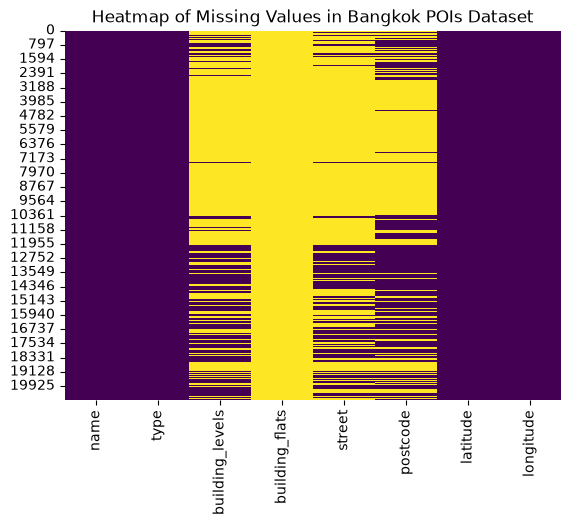

In [16]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title("Heatmap of Missing Values in Bangkok POIs Dataset")
plt.show()

In [19]:
df_pois = df[['name', 'type', 'latitude', 'longitude']]
df_pois

,name,type,latitude,longitude
0,Krungthep Thani Tower,condo/apartment,13.725496,100.567068
1,Le Raffiné Sukhumvit 24,condo/apartment,13.725908,100.567097
2,Central Bangna,mall,13.669582,100.634591
3,Big C,mall,13.669022,100.635843
4,ดิ ออฟฟิศเศส แอท เซ็นทรัลเวิลด์,office,13.745977,100.538330
...,...,...,...,...
20715,mall,mall,13.741014,100.495340
20716,mall,mall,13.741320,100.494774
20717,mall,mall,13.740106,100.497521
20718,บ้านส้มตำ,office,13.767758,100.395580


### 💾 บันทึกผลลัพธ์ข้อมูลคลีนระดับ Processed
ส่งออกข้อมูลที่ทำความสะอาดเรียบร้อยเป็นไฟล์ CSV พร้อมป้อนเข้าแบบจำลอง


In [ ]:
df_pois.to_csv("../../data/processed/bangkok_pois_clean.csv", index=False)